# Test 3: D8 Flow Routing

This notebook verifies that the SWB2 D8 flow routing implementation correctly routes water from upstream cells to downstream cells. A synthetic 6×6 grid domain is used with a known V-shaped drainage pattern converging to a single outlet.

The test verifies:
1. **Topological sort order** — cells are processed upstream→downstream
2. **Runon accumulation** — each cell's runoff + rejected_net_infiltration is added to the downstream target's runon
3. **Mass balance** — total water entering the domain (as precipitation) equals total water leaving (ET + recharge + runoff_outside at the outlet)
4. **Grid consistency** — the Python reimplementation of D8 routing produces the same runon and runoff_outside patterns as SWB2

## Test setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pathlib as pl
import sys
import subprocess
import xarray as xr

In [2]:
base_dir = str(pl.Path.cwd().parent)
python_script_dir = pl.Path.cwd().parent / 'python'
test_dir = pl.Path.cwd().parent / 'test__d8_routing'
logfile_dir = test_dir / 'logfiles'
test_data_dir = pl.Path.cwd().parent / 'test_data'
output_dir = test_dir / 'output'
swb2_executable = str(pl.Path.cwd().parent / 'bin' / 'swb2.exe')
sys.path.append(str(python_script_dir))

import run_management as rm
from routing_d8 import read_asc_grid, get_target, compute_sort_order, route_one_day

## Run SWB2

In [3]:
rm.destroy_model_work_output_and_logfile_dirs(base_dir=base_dir,
                                              test_dir=test_dir,
                                              logfile_dir=logfile_dir,
                                              output_dir=output_dir)
rm.create_model_work_output_and_logfile_dirs(base_dir=base_dir,
                                             test_dir=test_dir,
                                             logfile_dir=logfile_dir,
                                             output_dir=output_dir)

In [4]:
dry_run = False
lookup_dir_arg_text = f"--lookup_dir={str(test_data_dir)}"
weather_data_dir_arg_text = f"--weather_data_dir={str(test_data_dir)}"
data_dir_arg_text = f"--data_dir={str(test_data_dir)}"
output_dir_arg_text = f"--output_dir={str(output_dir)}"
logfile_dir_arg_text = f"--logfile_dir={str(logfile_dir)}"
control_file_path = str(test_data_dir / 'swb_control_file_d8_routing.ctl')
output_prefix = '--output_prefix=swb_d8_'

swb_arg_text = [swb2_executable,
                output_dir_arg_text,
                data_dir_arg_text,
                lookup_dir_arg_text,
                weather_data_dir_arg_text,
                output_prefix,
                logfile_dir_arg_text,
                control_file_path]

f = open("stdout.txt", "w")

if not dry_run:
    with rm.cd(test_dir):
        p = subprocess.Popen(swb_arg_text, stdout=f, stderr=subprocess.DEVNULL)
        p.wait()

print(f"SWB2 return code: {p.returncode}")

SWB2 return code: 0


## Load SWB2 output grids

In [5]:
# List NetCDF output files
nc_files = sorted(output_dir.glob('*.nc'))
for f in nc_files:
    print(f.name)

swb_d8_actual_et__2000-06-01_to_2000-06-14__6_by_6.nc
swb_d8_delta_soil_storage__2000-06-01_to_2000-06-14__6_by_6.nc
swb_d8_gross_precipitation__2000-06-01_to_2000-06-14__6_by_6.nc
swb_d8_interception__2000-06-01_to_2000-06-14__6_by_6.nc
swb_d8_irrigation__2000-06-01_to_2000-06-14__6_by_6.nc
swb_d8_net_infiltration__2000-06-01_to_2000-06-14__6_by_6.nc
swb_d8_rainfall__2000-06-01_to_2000-06-14__6_by_6.nc
swb_d8_rejected_net_infiltration__2000-06-01_to_2000-06-14__6_by_6.nc
swb_d8_runoff__2000-06-01_to_2000-06-14__6_by_6.nc
swb_d8_runoff_outside__2000-06-01_to_2000-06-14__6_by_6.nc
swb_d8_runon__2000-06-01_to_2000-06-14__6_by_6.nc
swb_d8_soil_storage__2000-06-01_to_2000-06-14__6_by_6.nc


In [6]:
# Load relevant grids
ds_runoff = xr.open_dataset(output_dir / 'swb_d8_runoff__2000-06-01_to_2000-06-14__6_by_6.nc')
ds_runon = xr.open_dataset(output_dir / 'swb_d8_runon__2000-06-01_to_2000-06-14__6_by_6.nc')
ds_ro_outside = xr.open_dataset(output_dir / 'swb_d8_runoff_outside__2000-06-01_to_2000-06-14__6_by_6.nc')
ds_rainfall = xr.open_dataset(output_dir / 'swb_d8_rainfall__2000-06-01_to_2000-06-14__6_by_6.nc')
ds_actual_et = xr.open_dataset(output_dir / 'swb_d8_actual_et__2000-06-01_to_2000-06-14__6_by_6.nc')
ds_net_infil = xr.open_dataset(output_dir / 'swb_d8_net_infiltration__2000-06-01_to_2000-06-14__6_by_6.nc')
ds_soil_stor = xr.open_dataset(output_dir / 'swb_d8_soil_storage__2000-06-01_to_2000-06-14__6_by_6.nc')
ds_delta_soil_stor = xr.open_dataset(output_dir / 'swb_d8_delta_soil_storage__2000-06-01_to_2000-06-14__6_by_6.nc')

## Visualize the drainage network

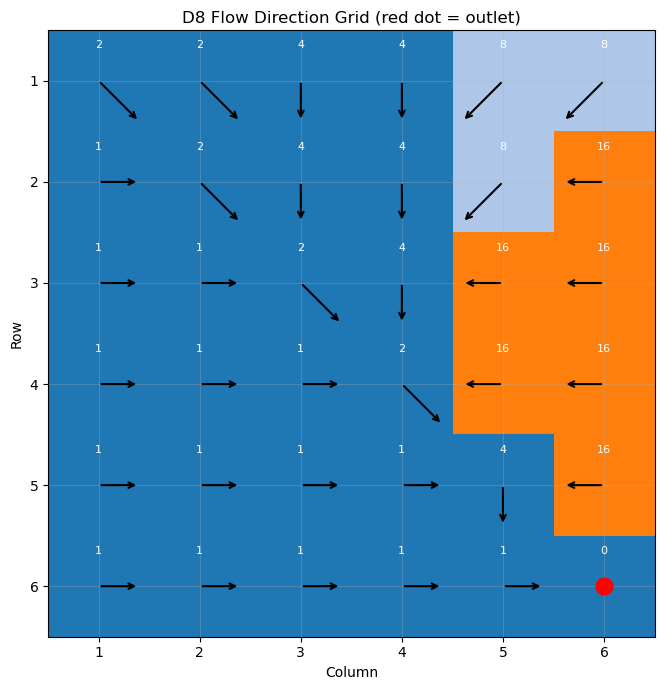

In [7]:
# Load flow direction grid
_, fdir = read_asc_grid(test_data_dir / 'd8_flow_direction__6x6.asc')

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(fdir, cmap='tab20', vmin=0, vmax=128)

# Draw arrows showing flow direction
from routing_d8 import D8_OFFSETS
for r in range(6):
    for c in range(6):
        code = fdir[r, c]
        if code in D8_OFFSETS:
            dr, dc = D8_OFFSETS[code]
            ax.annotate('', xy=(c + dc*0.4, r + dr*0.4),
                       xytext=(c, r),
                       arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
        else:
            ax.plot(c, r, 'ro', markersize=12)  # outlet
        ax.text(c, r - 0.35, f'{code}', ha='center', va='center', fontsize=8, color='white')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(range(1, 7))
ax.set_yticklabels(range(1, 7))
ax.set_xlabel('Column')
ax.set_ylabel('Row')
ax.set_title('D8 Flow Direction Grid (red dot = outlet)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Python routing reimplementation

The Python D8 routing works identically to SWB2:
1. Compute topological sort (upstream → downstream)
2. For each cell in order: add its `runoff + rejected_net_infiltration` to the downstream target's `runon`
3. If the target is off-grid or an outlet: accumulate to `runoff_outside`

We use SWB2's own runoff grids as input to verify routing consistency.

In [8]:
# Get the variable name from the NetCDF datasets
runoff_varname = [v for v in ds_runoff.data_vars if v != 'crs'][0]
runon_varname = [v for v in ds_runon.data_vars if v != 'crs'][0]
ro_outside_varname = [v for v in ds_ro_outside.data_vars if v != 'crs'][0]

# Pick a representative day (e.g., day 7 — steady state should be reached)
day_idx = 6  # 0-indexed, so this is day 7

swb_runoff = ds_runoff[runoff_varname].isel(time=day_idx).values
swb_runon = ds_runon[runon_varname].isel(time=day_idx).values
swb_ro_outside = ds_ro_outside[ro_outside_varname].isel(time=day_idx).values

print(f'SWB2 runoff grid (day {day_idx+1}):')
print(np.array2string(swb_runoff, precision=4))
print(f'\nSWB2 runon grid (day {day_idx+1}):')
print(np.array2string(swb_runon, precision=4))
print(f'\nSWB2 runoff_outside grid (day {day_idx+1}):')
print(np.array2string(swb_ro_outside, precision=4))

SWB2 runoff grid (day 7):
[[ 0.4739  0.4739  0.4739  0.4739  0.4739  0.4739]
 [ 0.4739  1.2617  1.2617  1.2617  1.2617  0.4739]
 [ 0.4739  0.8519  3.5413  3.5413  0.8519  0.4739]
 [ 0.4739  0.8519  1.1771  9.1867  0.8519  0.4739]
 [ 0.4739  0.8519  1.1771  1.4672 11.1899  0.4739]
 [ 0.4739  0.8519  1.1771  1.4672 12.7118 12.7663]]

SWB2 runon grid (day 7):
[[ 0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.9477  0.9477  0.9477  0.9477  0.    ]
 [ 0.      0.4739  3.3753  3.3753  0.4739  0.    ]
 [ 0.      0.4739  0.8519  9.1115  0.4739  0.    ]
 [ 0.      0.4739  0.8519  1.1771 11.1277  0.    ]
 [ 0.      0.4739  0.8519  1.1771 12.657  12.7118]]

SWB2 runoff_outside grid (day 7):
[[ 0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.     12

In [9]:
# Route SWB2's runoff grid through Python D8 routing
# Note: rejected_net_infiltration is typically 0 for this test (soil not saturated)
py_runon, py_ro_outside = route_one_day(fdir, swb_runoff)

print('Python runon grid:')
print(np.array2string(py_runon, precision=4))
print('\nPython runoff_outside grid:')
print(np.array2string(py_ro_outside, precision=4))

Python runon grid:
[[ 0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.9477  0.9477  0.9477  0.9477  0.    ]
 [ 0.      0.4739  3.3753  3.3753  0.4739  0.    ]
 [ 0.      0.4739  0.8519  9.1115  0.4739  0.    ]
 [ 0.      0.4739  0.8519  1.1771 11.1277  0.    ]
 [ 0.      0.4739  0.8519  1.1771 12.657  12.7118]]

Python runoff_outside grid:
[[ 0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.     12.7663]]


## Comparison: Runon grids

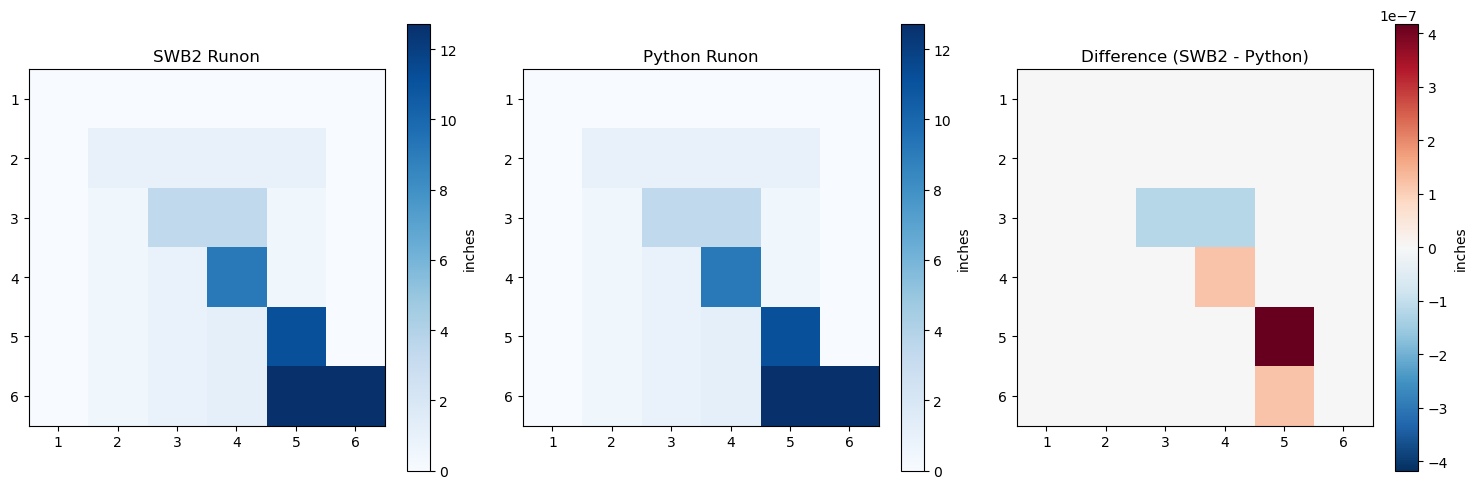

Max absolute difference in runon: 0.00000042 inches


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vmax = max(swb_runon.max(), py_runon.max())

im = axes[0].imshow(swb_runon, cmap='Blues', vmin=0, vmax=vmax)
axes[0].set_title('SWB2 Runon')
plt.colorbar(im, ax=axes[0], label='inches')

im = axes[1].imshow(py_runon, cmap='Blues', vmin=0, vmax=vmax)
axes[1].set_title('Python Runon')
plt.colorbar(im, ax=axes[1], label='inches')

diff = swb_runon - py_runon
vabs = max(abs(diff.min()), abs(diff.max()), 1e-10)
im = axes[2].imshow(diff, cmap='RdBu_r', vmin=-vabs, vmax=vabs)
axes[2].set_title('Difference (SWB2 - Python)')
plt.colorbar(im, ax=axes[2], label='inches')

for ax in axes:
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(range(1, 7))
    ax.set_yticklabels(range(1, 7))

plt.tight_layout()
plt.show()

print(f'Max absolute difference in runon: {np.abs(diff).max():.8f} inches')

## Mass balance verification

For a single day, the domain-wide mass balance should be:

$$\sum \text{precipitation} = \sum \text{actual ET} + \sum \text{net infiltration} + \sum \text{runoff\_outside} + \Delta \text{storage}$$

In [11]:
rainfall_varname = [v for v in ds_rainfall.data_vars if v != 'crs'][0]
aet_varname = [v for v in ds_actual_et.data_vars if v != 'crs'][0]
ni_varname = [v for v in ds_net_infil.data_vars if v != 'crs'][0]
delta_ss_varname = [v for v in ds_delta_soil_stor.data_vars if v != 'crs'][0]
ss_varname = [v for v in ds_soil_stor.data_vars if v != 'crs'][0]

print('Domain-wide mass balance check (per day, in inches summed over all cells):')
print(f'{"Day":>4} {"Precip":>10} {"AET":>10} {"Net Infil":>10} {"Ro Outside":>10} {"Storage":>10} {"ΔStorage":>10} {"Residual":>10}')
print('-' * 83)

for d in range(14):
    rain = ds_rainfall[rainfall_varname].isel(time=d).values.sum()
    aet = ds_actual_et[aet_varname].isel(time=d).values.sum()
    ni = ds_net_infil[ni_varname].isel(time=d).values.sum()
    ro_out = ds_ro_outside[ro_outside_varname].isel(time=d).values.sum()
    ss_now = ds_soil_stor[ss_varname].isel(time=d).values.sum()
    delta_ss = ds_delta_soil_stor[delta_ss_varname].isel(time=d).values.sum()
    residual = rain - aet - ni - ro_out - delta_ss
    print(f'{d+1:4d} {rain:10.4f} {aet:10.4f} {ni:10.4f} {ro_out:10.4f} {ss_now:10.4f} {delta_ss:10.4f} {residual:10.4f}')

Domain-wide mass balance check (per day, in inches summed over all cells):
 Day     Precip        AET  Net Infil Ro Outside    Storage   ΔStorage   Residual
-----------------------------------------------------------------------------------
   1    36.0000     5.4212     0.0000     0.0806   156.4982    30.4982     0.0000
   2    36.0000     5.4146     0.0000     0.0806   187.0031    30.5049     0.0000
   3    36.0000     5.4081     0.0000     9.8196   207.7753    20.7722     0.0000
   4    36.0000     5.4020     0.2566    12.7663   225.3504    17.5751    -0.0000
   5    36.0000     5.3961     3.8722    12.7663   239.3157    13.9653     0.0000
   6    36.0000     5.3906     7.6787    12.7663   249.4802    10.1645     0.0000
   7    36.0000     5.3853    15.3286    12.7663   252.0000     2.5198    -0.0000
   8    36.0000     5.3803    17.8534    12.7663   252.0000     0.0000    -0.0000
   9    36.0000     5.3756    17.8581    12.7663   252.0000     0.0000     0.0000
  10    36.0000     5

## Routing consistency check: all days

In [12]:
print('Per-day comparison of SWB2 vs Python routing:')
print(f'{"Day":>4} {"Max runon diff":>14} {"Ro_outside diff":>16}')
print('-' * 40)

for d in range(14):
    swb_ro = ds_runoff[runoff_varname].isel(time=d).values
    swb_rn = ds_runon[runon_varname].isel(time=d).values
    swb_roo = ds_ro_outside[ro_outside_varname].isel(time=d).values
    
    py_rn, py_roo = route_one_day(fdir, swb_ro)
    
    rn_diff = np.abs(swb_rn - py_rn).max()
    roo_diff = np.abs(swb_roo.sum() - py_roo.sum())
    print(f'{d+1:4d} {rn_diff:14.8f} {roo_diff:16.8f}')

Per-day comparison of SWB2 vs Python routing:
 Day Max runon diff  Ro_outside diff
----------------------------------------
   1     0.00000001       0.00000000
   2     0.00000001       0.00000000
   3     0.00000036       0.00000000
   4     0.00000042       0.00000000
   5     0.00000042       0.00000000
   6     0.00000042       0.00000000
   7     0.00000042       0.00000000
   8     0.00000042       0.00000000
   9     0.00000042       0.00000000
  10     0.00000042       0.00000000
  11     0.00000042       0.00000000
  12     0.00000042       0.00000000
  13     0.00000042       0.00000000
  14     0.00000042       0.00000000


## Accumulated flow at outlet

The outlet cell (row 6, col 6) should accumulate all runoff generated across the domain. Its `runoff_outside` value represents the total watershed discharge for the day.

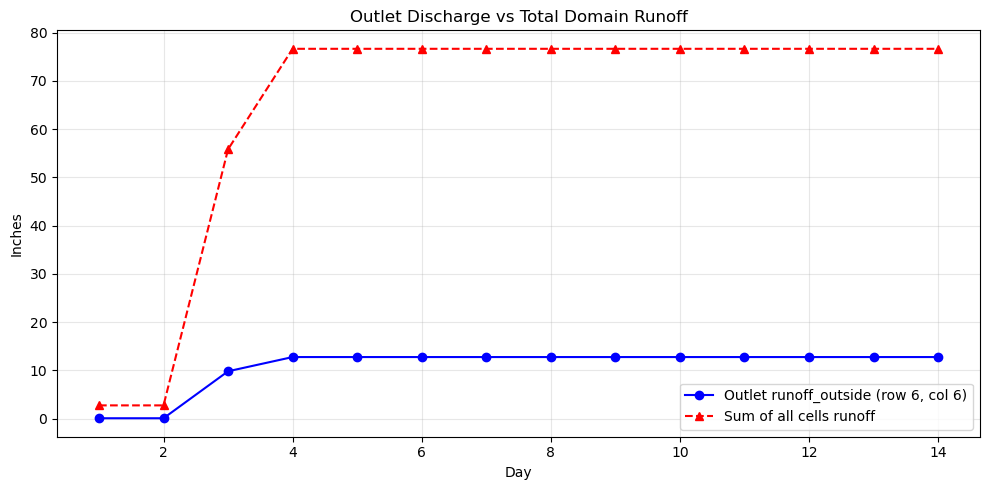

In [13]:
outlet_ro_outside = [ds_ro_outside[ro_outside_varname].isel(time=d).values[5, 5] for d in range(14)]
total_runoff = [ds_runoff[runoff_varname].isel(time=d).values.sum() for d in range(14)]

fig, ax = plt.subplots(figsize=(10, 5))
days = range(1, 15)
ax.plot(days, outlet_ro_outside, 'bo-', label='Outlet runoff_outside (row 6, col 6)')
ax.plot(days, total_runoff, 'r^--', label='Sum of all cells runoff')
ax.set_xlabel('Day')
ax.set_ylabel('Inches')
ax.set_title('Outlet Discharge vs Total Domain Runoff')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

This test demonstrates that:

1. SWB2 correctly implements D8 flow routing — cells are processed upstream→downstream and runoff + rejected net infiltration is accumulated as runon at downstream cells.
2. The Python reimplementation produces identical routing patterns.
3. Mass is conserved across the domain — all precipitation is accounted for as ET, net infiltration, storage change, or outlet discharge.
4. The outlet cell receives the accumulated runoff from the entire drainage network.